In [35]:
### OCR
## OCR 간단 예제
import numpy as np
import cv2
from PIL import Image
import pytesseract

def create_sample_image():
    """테스트용 샘플 이미지 생성"""

    # 흰색 배경 이미지 생성 (높이 200px, 너비 600px, 3채널 RGB)
    # np.ones(): 모든 값이 1인 배열 생성, * 255로 흰색(255,255, 255) 만들기
    image = np.ones((200, 600, 3), dtype=np.uint8) * 255

    # OpenCV를 사용하여 이미지에 텍스트 추가
    font = cv2.FONT_HERSHEY_SIMPLEX # 기본 sans-serif 폰트

    # cv2.putText(): 이미지에 텍스트 그리기
    # 매개변수: (이미지, 텍스트, 시작좌표(x,y), 폰트, 크기, 색상(BGR), 두께)
    cv2.putText(image, 'Hello OCR World!', (50, 100), font, 2, (0, 0, 0), 3)
    cv2.putText(image, 'This is a test image.', (50, 150), font, 1, (0, 0, 0), 2)

    # 생성된 이미지를 파일로 저장
    cv2.imwrite('sample_text.jpg', image)

    return image

def basic_ocr_example():
    """가장 기본적인 OCR 예제"""

    # 샘플 이미지 생성 (텍스트가 포함된 이미지)
    # 실제로는 파일에서 읽어옵니다
    image_path = "sample_text.jpg" # 실제 이미지 경로

    # cv2.imread(): 파일에서 이미지 읽기 (BGR 형식으로 로드)
    image = cv2.imread(image_path)

    # 이미지 파일이 존재하지 않는 경우 처리
    if image is None:
        print("이미지를 찾을 수 없습니다. 샘플 이미지를 생성합니다.")
        # 샘플 이미지 생성
        image = create_sample_image()

    # pytesseract.image_to_string(): OCR의 핵심 함수
    # 이미지에서 텍스트를 추출하여 문자열로 반환
    # 매개변수:
    # - image: 입력 이미지 (OpenCV 또는 PIL 형식)
    # - Lang: 인식할 언어 코드 ('eng'=영어, 'kor'=한국어, 'kor+eng'=다중언어)
    
    
    text = pytesseract.image_to_string(image, lang='eng')

    print("인식된 텍스트:")
    print(text)

    return text, image

text, image = basic_ocr_example()


인식된 텍스트:
Hello OCR World!

This is a test image.



{'level': [1], 'page_num': [1], 'block_num': [0], 'par_num': [0], 'line_num': [0], 'word_num': [0], 'left': [0], 'top': [0], 'width': [400], 'height': [100], 'conf': [-1], 'text': ['']}
LOW_QUALITY:
 텍스트: ''
 평균 신뢰도: 0.0%



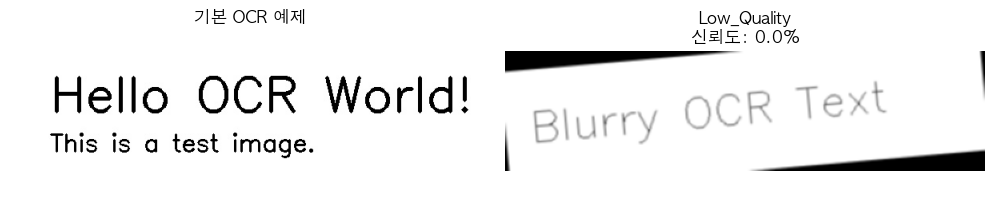

In [14]:
## 품질에 따른 OCR 테스트
import matplotlib.pyplot as plt

def create_high_quality_sample():
    """고품질 샘플 이미지 (OCR에 최적화된 조건)"""

    # 작은 크기의 깨끗한 흰색 배경 이미지 생성
    image = np.ones((100, 400, 3), dtype=np.uint8) * 255

    font = cv2.FONT_HERSHEY_SIMPLEX
    # 선명한 검은색 텍스트, 적절한 크기와 두께
    cv2.putText(image, 'Perfect OCR Text', (20, 60), font, 1.2, (0, 0, 0), 2)
    cv2.imwrite('high_quality_sample.jpg', image)

    return image

def create_medium_quality_sample():
    """중간품질 샘플 이미지 (약간의 노이즈 추가)"""

    image = np.ones((100, 400, 3), dtype=np.uint8) * 255

    # 가우시안 노이즈 추가로 실제 스캔 문서의 품질 모방
    # np.random.normal(): 평균 0, 표준편차 15의 정규분포 노이즈 생성
    noise = np.random.normal(0, 15, image.shape).astype(np.uint8)
    # cv2.add(): 이미지에 노이즈 추가 (오버플로우 방지)
    image = cv2.add(image, noise)

    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(image, 'Noisy OCR Text', (20, 60), font, 1.2, (0, 0, 0), 2)
    cv2.imwrite('medium_quality_sample.jpg', image)

    return image

def create_low_quality_sample():
    """저품질 샘플 이미지 (노이즈 + 기울기 + 블러)"""

    image = np.ones((100, 400, 3), dtype=np.uint8) * 255

    # 심한 노이즈 추가 (표준편차 30으로 증가)
    noise = np.random.normal(0, 30, image.shape).astype (np.uint8)
    image = cv2.add(image, noise)

    font = cv2.FONT_HERSHEY_SIMPLEX
    # 회색 텍스트로 대비 감소 (50,50,50), 얇은 두께(1)
    cv2.putText(image, 'Blurry OCR Text', (20, 60), font, 1.2, (50, 50, 50), 1)

    # 이미지 회전으로 기울기 추가 (실제 스캔 시 발생하는 기울기 모방)
    rows, cols = image.shape[:2]
    # cv2.getRotation Matrix2D(): 회전 변환 행렬 생성
    # 매개변수: (회전 중심점, 회전 각도, 크기 배율)
    M = cv2.getRotationMatrix2D((cols/2, rows/2), 5, 1)
    # cv2.warpAffine(): 아핀 변환 적용 (회전 실행)
    image = cv2.warpAffine(image, M, (cols, rows))

    # 가우시안 블러 추가로 초점 흐림 효과
    # cv2.Gaussian Blur(): 가우시안 커널을 사용한 블러 처리
    # 매개변수: (이미지, 커널 크기(3x3), X/Y 방향 표준편차(0=자동계산))
    image = cv2.GaussianBlur(image, (3, 3), 0)
    cv2.imwrite('low_quality_sample.jpg', image)

    return image

def ocr_quality_demo():
    """OCR 품질 비교 데모"""

    # 다양한 품질의 샘플 이미지 생성하여 OCR 성능 비교
    samples = {
        'high_quality': create_high_quality_sample(),       # 고품질 이미지
        'medium_quality': create_medium_quality_sample(),   # 중간품질 이미지 (노이즈 포함)
        'low_quality': create_low_quality_sample()          # 저품질 이미지 (노이즈+기울기+블러)
    }
    results = {}
    for quality, image in samples.items():
        # 각 이미지에 대해 OCR 실행
        text = pytesseract.image_to_string(image, lang='eng')

    # pytesseract.image_to_data(): OCR 결과의 상세 정보를 딕셔너리로 반환
    # 반환 정보: 텍스트, 좌표, 크기, 신뢰도 등
    # Output.DICT: 결과를 파이썬 딕셔너리 형태로 반환
    data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)
    print(data) # 딕셔너리 형태로 반환

    # 신뢰도(confidence) 점수 추출 및 평균 계산
    # conf > 0인 값들만 필터링 (유효한 텍스트 영역만)
    #
    # === Confidence 값의 의미 ===
    # 양수 (0-100): 실제 텍스트로 인식된 영역의 신뢰도
    #   - 0: 불확실하지만 텍스트일 가능성 있음
    #   - 100: 완전히 확신하는 인식 결과
    # 음수(주로 -1): 텍스트가 아닌 구조적 요소
    #  - 페이지 레벨 (Level=1): 전체 페이지 영역
    #  - 블록 레벨 (Level=2): 텍스트 블록 영역
    #  - 단락 레벨 (Level=3): 단락 영역
    #  - 줄 레벨 (Level=4): 텍스트 줄 영역
    #  - 실제 단어만 Level=5에서 양수 confidence를 가짐
    confidences = [int(conf) for conf in data['conf'] if int(conf) > 0]
    avg_confidence = np.mean (confidences) if confidences else 0

    # 결과 저장
    results[quality] = {
        'text': text.strip(),           # 인식된 텍스트 (앞뒤 공백 제거)
        'confidence': avg_confidence,   # 평균 신뢰도 점수 (0-100)
        'image': image                  # 원본 이미지
    }

    print(f"{quality.upper()}:")
    print(f" 텍스트: '{text.strip()}'")
    print(f" 평균 신뢰도: {avg_confidence:.1f}%")
    print()

    return results

# 다양한 품질 조건에서의 OCR 성능 비교 실행
quality_results = ocr_quality_demo()

#=== 결과 시각화 ===
# matplotlib를 사용하여 OCR 결과를 시각적으로 표시
plt.figure(figsize=(15, 10)) # 전체 그림 크기 설정 (가로 15인치, 세로 10인치)

# 한글 폰트 설정 (Windows 환경의 맑은 고딕 사용)
#matplotlib에서 한글이 깨지지 않도록 폰트 지정
plt.rc('font', family='AppleGothic')

# 서브플롯 배치: 2행 3열 그리드로 구성
# 기본 예제 결과 표시 (첫 번째 위치)
plt.subplot(2, 3, 1)
#OpenCV는 BGR 형식이므로 RGB로 변환하여 matplotlib에서 올바른 색상 표시
#cv2.cvtColor(): 색상 공간 변환 (BGR RGB)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('기본 OCR 예제')
plt.axis('off') #축 눈금과 레이블 숨기기

# 품질별 비교 결과 표시 (2-4번째 위치)
for i, (quality, result) in enumerate (quality_results.items(), 2):
    plt.subplot(2, 3, i) #서브플롯 위치 지정

    # 이미지 표시 (BGR → RGB 변환)
    plt.imshow(cv2.cvtColor(result['image'], cv2.COLOR_BGR2RGB))

    # 품질 유형과 신뢰도를 포함한 제목 설정
    #.title(): 첫 글자를 대문자로 변환
    plt.title(f'{quality.title()}\n신뢰도: {result["confidence"]:.1f}%')
    plt.axis('off') #축 표시 제거

# 서브플롯 간 간격 자동 조정으로 겹침 방지
plt.tight_layout()
#그래프 화면에 표시
plt.show()

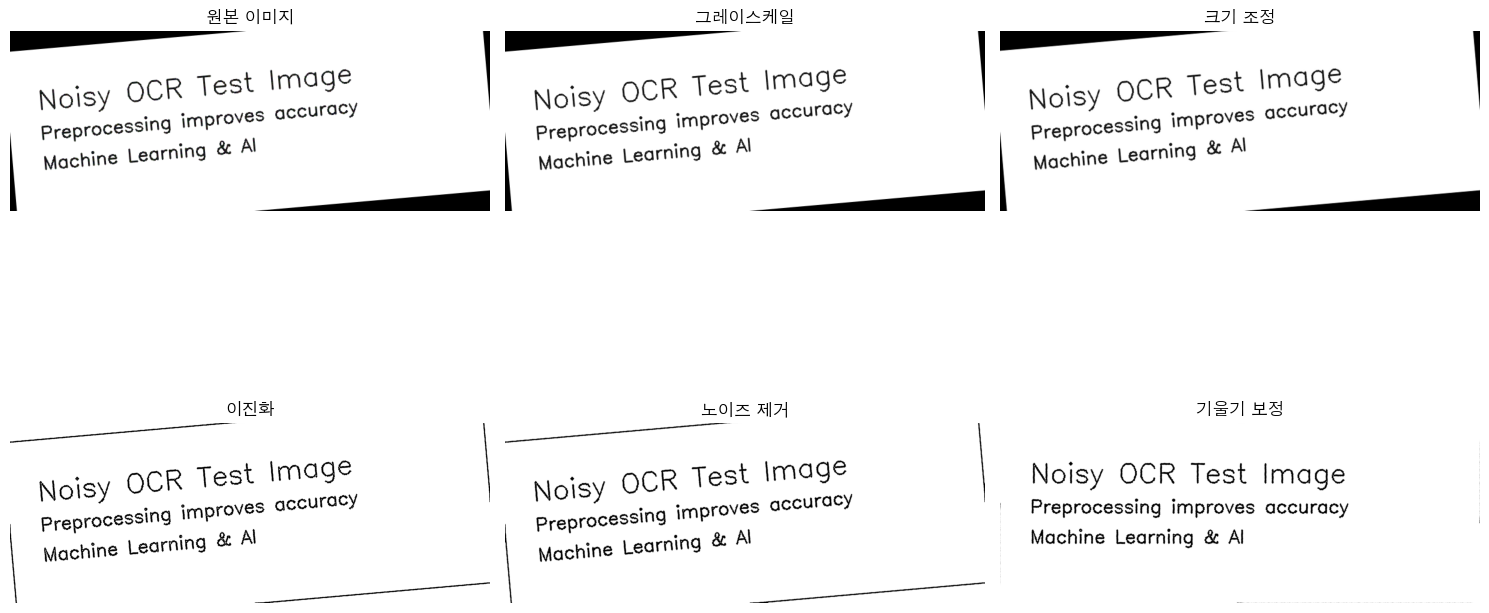

전처리 전 OCR 결과:
'a —™\nCR Test Image\n\necuracy\n\nNoisy O\nPreprocessing improves 4\nMachine Learning & Al\n\n———\n'

전처리 후 OCR 결과: 
'Noisy OCR Test Image\nPreprocessing improves accuracy\nMachine Learning & Al\n'


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(800, 2133), dtype=uint8)

In [25]:
## 전처리 예제
class OCRPreprocessor:
    def __init__(self):
        pass

    def convert_to_grayscale(self, image):
        """컬러 이미지를 그레이스케일로 변환"""
        # 이미지 차원 확인 (3차원 컬러, 2차원=그레이스케일)
        if len(image.shape) == 3:
            # BGR을 그레이스케일로 변환
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            # 이미 그레이스케일인 경우 복사본 생성
            gray = image.copy()
        return gray
            
    def apply_threshold(self, image, method='adaptive'):
        """이미지에 이진화 처리를 적용하여 흑백으로 변환"""
        gray = self.convert_to_grayscale(image)
        if method == 'simple':
            # 단순 임계값: 127보다 밝으면 255(흰색), 어두우면 (검은색)
            thresh = cv2.threshold (gray, 127, 255, cv2.THRESH_BINARY)
            #127 : 임계값
            #255 : 최대값
            # cv2.THRESH_BINARY : 입력 이미지의 픽셀 값이 임계값보다 크면 255, 작으면
            #_: 임계값 반환
            #thresh : 이진화된 이미지 반환
        elif method == 'adaptive':
            # 적응적 임계값: 각 픽셀 주변 영역의 가중 평균을 기준으로 임계값 결정
            # 11x11 영역의 가우시안 가중 평균에서 2를 뺀 값을 임계값으로 사용
            thresh = cv2.adaptiveThreshold(
                gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY, 11, 2
            )
            # adaptive Threshold 매개변수: 그레이스케일 이미지, 최대값, 임계값 방법, 이진화 방법, 영역 크기, 상수 값
            # gray : 그레이스케일 이미지
            #255 : 최대값
            #cv2.ADAPTIVE_THRESH_GAUSSIAN_C: 가우시안 가중 평균 임계값
            # cv2.THRESH_BINARY: 이진화 방법
            #11: 영역 크기
            #2: 상수 값
            #thresh: 이진화된 이미지
        elif method == 'otsu':
            #Otsu 방법: 히스토그램 분석으로 최적의 임계값 자동 선택
            # 히스토그램 분석: 이미지의 픽셀 값 분포를 분석하여 최적의 임계값을 찾는 방법
            _, thresh = cv2.threshold(
                gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )
            #threshold 매개변수: 그레이스케일 이미지, 임계값, 최대값, 이진화 방법
            # cv2.THRESH_BINARY + cv2.THRESH_OTSU : 이진화 방법
            #: 임계값 반환
            #thresh : 이진화된 이미지 반환
        return thresh
    
    def remove_noise(self, image):
        """이진화된 이미지에서 노이즈를 제거"""
        #3x3 구조 요소 생성 (모폴로지 연산용)
        # 모폴로지 연산 : 이미지의 픽셀 값을 변경하는 연산
        kernel = np.ones((3, 3), np.uint8)
        # 열림 연산 적용: 작은 노이즈 점들을 제거
        # 먼저 침식으로 작은 객체를 제거하고, 팽창으로 원래 크기 복원
        #침식 : 이미지의 픽셀 값이 0인 경우 주변 픽셀 값을 0으로 변경
        #팽창 : 이미지의 픽셀 값이 0이 아닌 경우 주변 픽셀 값을 0이 아닌 값으로 변경
        opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
        #닫힘 연산 추가: 텍스트 내부의 작은 구멍들을 메움
        #먼저 팽창으로 구멍을 메우고, 침식으로 원래 크기 복원
        closing = cv2.morphologyEx (opening, cv2.MORPH_CLOSE, kernel)
        # 메디안 필터 적용: 소금 후추 노이즈 제거에 효과적
        # 3x3 영역의 중앙값으로 노이즈 제거 (가우시안 블러보다 에지 보존 효과)
        denoised = cv2.GaussianBlur(closing, (3, 3), 0)
        # GaussianBlur 매개변수 : 이미지, 커널 크기, sigmax
        #closing: 이미지
        #(3,3): 커널 크기
        #0: sigmaX
        #denoised: 노이즈 제거된 이미지
        return denoised
    
    def correct_skew(self, image):
        """이미지의 기울기를 자동으로 보정"""
        # Canny 에지 검출: 50-150 임계값으로 윤곽선 추출
        edges = cv2.Canny (image, 50, 150, apertureSize=3)
        # Canny 매개변수: 그레이스케일 이미지, 최소 임계값, 최대 임계값, 커널 크기
        #50: 최소 임계값
        #150 : 최대 임계값
        # apertureSize=3 : 커널 크기
        #edges: 에지 이미지
        #허프 변환으로 직선 검출
        lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=100)
        # HoughLines 매개변수 : 에지 이미지, 거리 해상도, 각도 해상도, 최소 투표 수
        #1 : 거리 해상도 (1픽셀 단위로 거리를 측정)
        #np.pi/180: 각도 해상도 1도 (파이/180도, 즉 1도 단위로 각도를 측정)
        # threshold=100 : 최소 투표 수(최소 100개의 점이 있어야 직선으로 인식)
        #Lines : 직선 검출 결과
        if lines is not None:
            # 검출된 직선들의 기울기 각도 계산
            angles = []
            for rho, theta in lines[:, 0]:
                # 허프 변환에서 theta의 의미:
                #theta = 0도 (0 radian) → 수직선 (1)
                #theta = 90도 (π/2 radian) → 수평선 (-)
                #theta = 180도 (π radian) → 다시 수직선
                # 이미지 회전에서 각도의 의미:
                #도 → 수평선 기준(-)
                #90도 수직선 기준 (1)
                #양수 시계방향 회전
                #음수 반시계방향 회전
                #즉, 허프 변환은 수직선을 도로 보지만, 이미지 회전은 수평선을 도로 보기 때문에 -90도 보정
                angle = np.degrees (theta) - 90
                angles.append(angle)
            # 중앙값으로 기울기 보정 (이상값에 강건함)
            # 이상 각도가 있을 수 경우, 평균 값이 왜곡될 수 있기 때문에 중앙값을 사용
            median_angle = np.median(angles)
            # 이미지 중심점을 기준으로 회전 변환 행렬 생성
            (h, w) = image.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D (center, median_angle, 1.0)
            # INTER_CUBIC: 고품질 보간, BORDER_REPLICATE: 가장자리 복제
            rotated = cv2.warpAffine(image, M, (w, h),
                                    flags=cv2.INTER_CUBIC,
                                    borderMode=cv2.BORDER_REPLICATE)
            # warpAffine 매개변수: 이미지, 회전 행렬, 출력 이미지 크기, 보간법, 테두리 처리
            #image: 입력 이미지
            #M: 회전 행렬 (getRotation Matrix2D로 생성)
            #(w, h): 출력 이미지 크기
            #flags=cv2.INTER_CUBIC : 보간법 (회전 시 새로운 좌표의 픽셀 값 계산 방법)
            # INTER_CUBIC : 3차 보간법 (주변 4x4=16개 픽셀의 3차 함수로 고품질 계산)
            # borderMode=cv2.BORDER_REPLICATE: 테두리 처리 (이미지 경계 밖은 가장자리 픽셀로 채움)
            #rotated: 회전된 이미지
            return rotated
        # 직선을 검출하지 못한 경우 원본 반환
        return image
    
    def resize_image(self, image, target_height=800):
        """
        OCR 최적화를 위한 이미지 크기 조정
        OCR은 일정 크기 이상에서 성능이 좋아짐
        INTER_CUBIC 보간법으로 고품질 확대
        """
        # 현재 이미지의 높이와 너비 획득
        h, w = image.shape[:2]
        if h < target_height:
            # 이미지가 너무 작은 경우 크기 증가
            # 높이 기준으로 스케일 비율 계산
            scale = target_height /h
            new_w = int(w * scale)
            # INTER_CUBIC 보간법으로 고품질 리사이징
            resized = cv2.resize(image, (new_w, target_height), interpolation=cv2.INTER_CUBIC)
        else:
            # 이미지가 충분히 큰 경우 원본 유지
            resized = image
        return resized
    
    def visualize_preprocessing_steps(self, steps, step_names):
        """전처리 과정을 단계별로 시각화"""
        #2행 3열 서브플롯 생성 (15x10 인치 크기)
        plt.rc('font', family='AppleGothic')
        fig, axes = plt.subplots (2, 3, figsize=(15, 10))
        #fig: 전체 그래프 창(캔버스) - 크기, 레이아웃, 저장 등 전체 관리
        #axes: 개별 플롯 영역들의 배열 - 각 칸에 이미지를 그리는 공간 (2 * 3 = 67H)
        #figsize: 그래프 창 크기(가로 15인치, 세로 10인치)
        axes = axes.ravel() #2차원 배열을 1차원으로 변환
        #axes 값 변환 : 2차원 배열을 1차원 배열로 변환하여 각 칸에 이미지를 그리는 공간을 만들
        # 기존 아래 형태로 있으면 for 문으로 처리하기 어려움움
        # axes = [
        # [axes [0,0], axes [0,1], axes [0,2]],
        #첫 번째 행
        # [axes [1,0], axes [1, 1], axes [1,2]]
        #두 번째 행
        #]
        # axes.ravel() 결과
        #axes = [axes[0], axes [1], axes [2], axes [3], axes [4], axes [5]]
        #각 처리 단계별로 이미지 출력
        for i, (step, name) in enumerate (zip (steps, step_names)):
            if i < len(axes): # 서브플롯 개수 초과 방지
                if len(step.shape) == 3:
                    # 컬러 이미지: BGR을 RGB로 변환하여 출력
                    axes[i].imshow(cv2.cvtColor(step, cv2.COLOR_BGR2RGB))
                else:
                    #그레이스케일 이미지: gray 컬러맵 사용
                    axes[i].imshow(step, cmap='gray')
                #각 서브플롯에 제목 설정 및 축 숨김
                axes[i].set_title(name)
                axes[i].axis('off')
        # 레이아웃 자동 조정 및 출력
        plt.tight_layout()
        plt.show()
    
    def preprocess_pipeline(self, image, visualize=False):
        """전체 이미지 전처리 파이프라인 실행"""
        #각 처리 단계별 결과 저장용 리스트
        steps = []
        step_names = []
        #0. 원본 이미지 보존
        steps.append(image.copy())
        step_names.append('원본 이미지')
        #1. 그레이스케일 변환
        gray = self.convert_to_grayscale(image)
        steps.append(gray)
        step_names.append('그레이스케일')
        #2. OCR 최적화를 위한 크기 조정
        resized = self.resize_image(gray)
        steps.append(resized)
        step_names.append('크기 조정')
        #3. 적응적 이진화 처리 (지역적 밝기 변화에 강건)
        thresh = self.apply_threshold (resized, method='adaptive')
        steps.append(thresh)
        step_names.append('이진화')
        #4. 모폴로지 연산으로 노이즈 제거
        denoised = self.remove_noise(thresh)
        steps.append(denoised)
        step_names.append('노이즈 제거')
        #5. 허프 변환 기반 기울기 자동 보정
        corrected = self.correct_skew(denoised)
        steps.append(corrected)
        step_names.append('기울기 보정')
        # 시각화 옵션이 활성화된 경우 처리 과정 출력
        if visualize:
            self.visualize_preprocessing_steps (steps, step_names)
        return corrected
    
def create_noisy_sample_image():
    """테스트용 노이즈가 있는 샘플 이미지 생성"""
    #300x800 크기의 흰색 배경 이미지 생성 (RGB)
    image = np.ones((300, 800, 3), dtype=np.uint8) * 255
    # 다양한 크기와 위치에 텍스트 추가
    font = cv2.FONT_HERSHEY_SIMPLEX
    # 제목 텍스트 (크기 1.5, 굵기 2)
    cv2.putText(image, 'Noisy OCR Test Image', (50, 100), font, 1.5, (0, 0, 0), 2)
    # 부제목 텍스트 (크기 1.0, 굵기 2)
    cv2.putText(image, 'Preprocessing improves accuracy', (50, 150), font, 1, (0, 0, 0), 2)
    #내용 텍스트(크기 1.0, 굵기 2)
    cv2.putText(image, 'Machine Learning & AI', (50, 200), font, 1, (0, 0, 0), 2)
    # 0-50 범위의 랜덤 노이즈 생성 및 추가
    noise = np.random.randint(0, 50, image.shape, dtype=np.uint8)
    # random.randint: 0-50 범위의 랜덤 노이즈 생성
    #image.shape : 이미지 크기
    # dtype=np.uint8 : 노이즈 값 범위 (0-255)
    #noise : 노이즈 이미지
    #add : 이미지에 노이즈 추가
    #image: 원본 이미지
    noisy_image = cv2.add(image, noise)
    #add : 이미지에 노이즈 추가
    #image: 원본 이미지
    noisy_image = cv2.add(image, noise)
    #문서 스캔 상황을 모방한 5도 기울기 적용
    h, w = noisy_image.shape[:2]
    # 이미지 중심점
    center = (w // 2, h // 2)
    #5도 회전, 크기 유지 (center, 각도, 크기)
    M = cv2.getRotationMatrix2D (center, 5, 1.0)
    skewed_image = cv2.warpAffine (noisy_image, M, (w, h))
    #warpAffine 매개변수: 이미지, 회전 행렬, 출력 이미지 크기
    #noisy_image: 원본 이미지
    #M: 회전 행렬 (getRotationMatrix2D로 생성)
    #(w, h): 출력 이미지 크기
    # skewed_image: 회전된 이미지
    return skewed_image

# 사용 예제 함수들
def preprocessing_example():
    """OCR 전처리 예제 실행 함수"""

    # OCR 전처리기 인스턴스 생성
    preprocessor = OCRPreprocessor()
    #노이즈와 기울기가 있는 샘플 이미지 생성
    image = create_noisy_sample_image()
    # 전체 전처리 파이프라인 실행 (시각화 포함)
    processed_image = preprocessor.preprocess_pipeline(image, visualize=True)
    # OCR 라이브러리가 있는 경우 전후 비교
    try:
        import pytesseract
        #전처리 전 OCR 결과
        original_text = pytesseract.image_to_string(image)
        #전처리 후 OCR 결과
        processed_text = pytesseract.image_to_string(processed_image)
        print("전처리 전 OCR 결과:")
        print(repr(original_text))
        print("\n전처리 후 OCR 결과: ")
        print(repr(processed_text))
    except ImportError:
        print("pytesseract가 설치되지 않아 OCR 비교를 건너됩니다.")
        print("설치: pip install pytesseract")
    return processed_image

preprocessing_example()

In [ ]:
### Tesseract 엔진
## Tesseract


In [27]:
### CRNN 모델
## NVIDIA GPU 확인
import platform
import subprocess
def check_gpu_info():
    print(f"운영체제: {platform.system()} {platform.release()}")
    try:
        # nvidia-smi 실행
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            print("NVIDIA GPU 감지됨")
            print("GPU 정보:")
            print(result.stdout)
        else:
            print("NVIDIA GPU가 없거나 드라이버 문제")
    except FileNotFoundError:
        print("NVIDIA 드라이버가 설치되지 않음")
check_gpu_info()

# GPU 설치해도 CPU 사용 가능 (자동 전환)
import torch
#장치 자동 선택
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")
#강제로 CPU 사용하려면
device_cpu = torch.device('cpu')
#강제로 GPU 사용하려면 (GPU 있을 때만)
if torch.cuda.is_available():
    device_gpu = torch.device('cuda')
# 실제 사용 예시
# model = model.to(device)
# 자동으로 GPU/CPU 선택
# data = data.to (device)
# 데이터도 같은 장치로

운영체제: Darwin 24.6.0
NVIDIA 드라이버가 설치되지 않음
사용 장치: cpu


In [28]:
## Tensor
import torch
import numpy as np
#차원 (스칼라) - 단일 숫자
scalar = torch.tensor (5)
print(f"차원 (스칼라): {scalar}, 형태: {scalar.shape}")
#1차원 (벡터) - 일련의 숫자들
vector = torch.tensor ([1, 2, 3, 4])
print(f"1차원 (벡터): (vector), 형태: {vector.shape}")
#2차원 (행렬) - 표나 이미지의 한 채널
matrix = torch.tensor ([[1, 2, 3],[4, 5, 6]])
print(f"2차원 (행렬): {matrix}, 형태: {matrix.shape}")
#3차원 - 컬러 이미지 (높이, 너비, 채널)
image_3d = torch.tensor ([
[[255, 0, 0], #빨강 픽셀
[0, 255, 0]], #초록 픽셀
[[0, 0, 255], #파랑 픽셀
[255, 255, 0]]]) # 노랑 픽셀
print(f"3차원 (이미지): 형태 {image_3d.shape}")
#4차원 - 배치 이미지(배치, 채널, 높이, 너비)
batch_images = torch.randn(32, 3, 64, 128)
# 32개 이미지, RGB, 64x128
print(f"4차원 (배치): 형태 {batch_images.shape}")

차원 (스칼라): 5, 형태: torch.Size([])
1차원 (벡터): (vector), 형태: torch.Size([4])
2차원 (행렬): tensor([[1, 2, 3],
        [4, 5, 6]]), 형태: torch.Size([2, 3])
3차원 (이미지): 형태 torch.Size([2, 2, 3])
4차원 (배치): 형태 torch.Size([32, 3, 64, 128])


=== CRNN OCR 실습 ===

사용 디바이스: cpu

1. 합성 데이터셋 생성
훈련 데이터: 1000개, 테스트 데이터: 100개
문자 집합: 0123456789


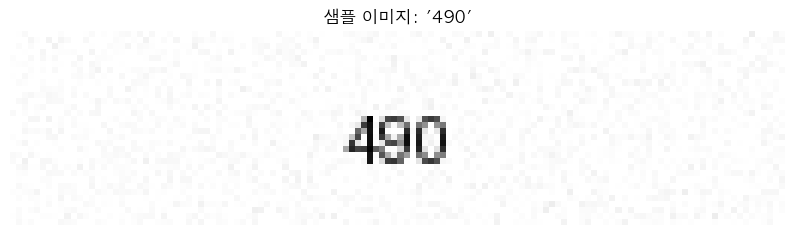


2. CRNN 모델 생성
모델 파라미터 수: 7,134,859

3. 모델 훈련

Epoch 1/30
Batch 0, Loss: 20.9252
평균 손실: 3.7007, 학습률: 0.000500

Epoch 2/30
Batch 0, Loss: 2.7255
평균 손실: 2.7181, 학습률: 0.000500

2 에포크 평가:
GT: '3580' | Pred: '' | X
GT: '791' | Pred: '' | X
GT: '1001' | Pred: '' | X
GT: '316' | Pred: '' | X
GT: '64' | Pred: '' | X
GT: '499' | Pred: '' | X
GT: '90' | Pred: '' | X
GT: '99' | Pred: '' | X
GT: '25' | Pred: '' | X
GT: '430' | Pred: '' | X
GT: '905' | Pred: '' | X
GT: '306' | Pred: '' | X
GT: '133' | Pred: '' | X
GT: '7242' | Pred: '' | X
GT: '714' | Pred: '' | X
GT: '50' | Pred: '' | X
GT: '969' | Pred: '' | X
GT: '760' | Pred: '' | X
GT: '841' | Pred: '' | X
GT: '8135' | Pred: '' | X
GT: '81' | Pred: '' | X
GT: '906' | Pred: '' | X
GT: '21' | Pred: '' | X
GT: '747' | Pred: '' | X
GT: '82' | Pred: '' | X
GT: '49' | Pred: '' | X
GT: '2970' | Pred: '' | X
GT: '217' | Pred: '' | X
GT: '7188' | Pred: '' | X
GT: '6475' | Pred: '' | X
GT: '22' | Pred: '' | X
GT: '815' | Pred: '' | X
GT: '017' | Pred: '

In [46]:
## CRNN 예제
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import string
import random

class CRNN(nn.Module):
    """CRNN 모델 구현 - CNN과 RNN을 결합한 텍스트 인식 모델"""
    def __init__(self, img_height, img_width, num_chars, num_classes, rnn_hidden=256):
        """
        CRNN 모델 초기화
        목적: OCR(광학 문자 인식)을 위한 신경망 모델 구조 정의
        필요성 : 이미지에서 텍스트를 순차적으로 인식하기 위해 CNN(특징 추출) + RNN(순서 정보) 결합 필요
        """
        super().__init__()
        self.img_height = img_height
        self.img_width = img_width
        self.num_chars = num_chars
        #num_chars: 인식할 문자의 종류 수
        self.num_classes = num_classes #문자 개수 + blank + EOS
        #num_classes: CTC용 클래스 수(문자 개수 + blank + EOS)
        #blank: 빈 문자 토큰
        #EOS: 문자열 종료 토큰
        #CNN 백본 (특징 추출기)
        # 백본 네트워크 : 이미지에서 시각적 특징을 추출하는 합성곱 신경망
        self.cnn = nn.Sequential(
            # Layer 1 - 기본 특징 추출
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            #1채널 -> 64채널
            #1: 입력 채널 수 (그레이스케일 이미지)
            #64: 출력 채널 수 (64개의 서로 다른 필터로 64개의 특징 맵 생성)
            # kernel_size: 필터 크기
            #stride: 필터 이동 거리
            # padding: 패딩 크기
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # 32x128 -> 16x64, 해상도 절반으로 축소 (2x2 크기의 최대 풀링)
            # Layer 2 -더 복잡한 특징 추출
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d (128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # 16x64
            #64채널 -> 128채널
            # Layer 3 고수준 특징 추출 - 8x32
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),    #128채널 -> 256채널
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # Layer 4 - 특징 정제
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1)),             # 8x32 4x32, 높이만 축소 (너비는 유지)
            # Layer 5 - 더 깊은 특징 추출
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),            #256채널 -> 512채널
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            # Layer 6 - 특징 강화
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1)), #4x32 2x32
            # Layer 7 - 최종 특징 맵 생성
            nn.Conv2d(512, 512, 2, 1, 0), nn.ReLU()            # 2x32 -> 1x31, 1차원 특징으로 변환
        )
        #RNN (순차 정보 처리)
        #텍스트의 순서 정보를 처리하는 양방향 LSTM
        self.rnn = nn.LSTM(512, rnn_hidden, bidirectional=True, batch_first=True)
        #512: 마지막 CNN 출력 채널 수 (입력 특징 차원)
        # rnn_hidden: 은닉 상태(hidden state) 차원 수(256)
        # - 실제 LSTM 내부에는 4개의 게이트가 있음: forget, input, output, cell
        # - 각 게이트마다 rnn_hidden 크기의 가중치 행렬이 필요
        # - 총 파라미터 수 = 4 × (input_size + hidden_size) x hidden_size
        # - 예: 4× (512 +256) x 256 = 786,432개 파라미터 (단방향 기준)
        # bidirectional=True: 양방향 LSTM (forward + backward)
        # - 파라미터 수가 2배가 됨 (각 방향마다 별도 LSTM)
        # - 출력 차원: 2 x rnn_hidden = 512
        # batch_first=True: 입력 형태 [batch, sequence, features]
        # - 데이터 배치를 첫 번째 차원으로 사용
        # - 예: [batch, sequence, features] -> [batch, sequence, features]
        # - 일반적인 RNN 입력 형태: [sequence, batch, features]를 CNN 출력과 맞추기 위해 변환
        # 출력 레이어 -RNN 출력을 문자 클래스로 변환
        self.linear = nn. Linear(rnn_hidden * 2, num_classes) # *2는 양방향 LSTM이므로
    
    def forward(self, x):
        """
        순전파 함수
        목적: 입력 이미지를 문자 시퀀스 확률로 변환
        필요성: CNN으로 특징을 추출하고 RNN으로 순서 정보를 처리하여 텍스트 인식 수행
        """
        #CNN으로 특징 추출
        conv_features = self.cnn(x) # [batch, 512, 1, width]
        #RNN 입력을 위해 차원 변경
        b, c, h, w = conv_features.size()
        #conv_features.size(): (batch_size, channels, height, width)
        conv_features = conv_features.view(b, c *h, w)
        # [batch, 512, width], 512개 features
        # conv_features.view(b, ch, w): (batch_size, channels height, width)
        #텐서의 값은 유지하면서 차원 변경
        # CNN 출력의 height(h)는 보통 1이 됨 (예: 1xw 이미지)
        #width는 시퀀스 길이로 사용 (글자가 순서대로 있는 축)
        # height x channels는 각 시퀀스 위치(= 너비 방향)에서의 feature 벡터 차원
        #예: [batch, 512, 1, 25] 각 "시퀀스(문자) 위치 25개"에 대해 512개의 feature를 가짐 [batch, 512, 25]
        conv_features = conv_features.permute(0, 2, 1) # [batch, width, 512], 각 위치마다 512개 특징
        #permute: 차원 순서 변경
        #0,2,1: 0번째 차원은 유지, 1번째 차원은 2번째 차원으로, 2번째 차원은 1번째 차원으로
        #예: [batch, 512, 25] [batch, 25, 512]
        # RNN으로 순차 정보 처리
        rnn_out, _ = self.rnn(conv_features) # [batch, width, hidden*2]
        #rnn_out: (batch_size, width, hidden_size * 2)
        # bidirectional=True 이므로 hidden_size* 2
        # 출력 레이어
        output = self.linear(rnn_out) # [batch, width, num_classes]
        #각 문자 위치에 대해 num_classes 클래스 중 하나를 예측
        output = F.log_softmax(output, dim=2)
        #로그 확률로 변환
        #dim=2: 마지막 차원(클래스 차원)에 대해 소프트맥스 적용
        #output: (batch_size, width, num_classes)
        return output
    
class SyntheticTextDataset (Dataset):
    """합성 텍스트 데이터셋 OCR 훈련용 인공 텍스트 이미지 생성"""
    def __init__(self, num_samples=1000, img_height=32, img_width=128, max_text_len=6):
        """
        합성 텍스트 데이터셋 초기화
        목적: OCR 모델 훈련을 위한 가상 텍스트 이미지 데이터 생성
        필요성: 실제 라벨링된 텍스트 이미지 데이터가 부족하므로 합성 데이터로 보완
        """
        self.num_samples = num_samples
        #num_samples: 생성할 샘플 수
        self.img_height = img_height
        #img_height : 이미지 높이
        self.img_width = img_width
        #img_width: 이미지 너비
        self.max_text_len = max_text_len
        #max_text_Len: 최대 텍스트 길이
        # 문자 집합 정의 (숫자만 - 학습 난이도 감소)
        self.chars = string.digits #0-9만 사용
        #문자를 인덱스로 매핑 (1부터 시작, e은 CTC blank용)
        self.char_to_idx = {char: idx+1 for idx, char in enumerate(self.chars)}
        # char_to_idx : 문자를 인덱스로 매핑
        #예: {'a': 1, 'b': 2, 'c': 3, ...}
        self.char_to_idx['<blank>'] = 0 # CTC blank 토큰
        # char_to_idx['<blank>']: 빈 문자 토큰
        #예: {'a': 1, 'b': 2, 'c': 3, ...}
        # 인덱스를 문자로 역매핑
        self.idx_to_char = {idx: char for char, idx in self.char_to_idx.items()}
        #idx_to_char: 인덱스를 문자로 역매핑
        #예: {1: 'a', 2: 'b', 3: 'c', ...}
        self.num_classes = len(self.chars) + 1 # +1 for blank
        #num_classes: 문자 개수 + blank + EOS
        #예: 26 + 1 + 1 = 28 (소문자 26개 + 빈 문자 1개 + 문자열 종료 1개)
        # 이미지 전처리 변환
        self.transform = transforms.Compose([
            transforms. ToTensor(), # PIL Image -> Tensor
            transforms.Normalize((0.5,), (0.5,)) # [-1,1] 범위로 정규화
        ])
        #transform: 이미지 전처리 변환
        #ToTensor(): PIL Image -> Tensor
        # PIL Image: 파이썬 이미지 라이브러리 Pillow (PIL)에서 제공하는 이미지 객체
        #Tensor: 파이토치에서 제공하는 텐서 객체
        # 텐서는 넘파이 배열과 유사한 텐서 연산을 지원하며, 자동미분 기능을 제공
        #텐서는 데이터를 효율적으로 처리하고 연산하기 위한 표준 데이터 구조
        # Normalize(): 픽셀 값을 [-1, 1] 범위로 정규화
        #예: [0, 255] → [-1, 1]

    def __len__(self):
        """
        데이터셋 크기 반환
        목적: DataLoader가 데이터셋 크기를 알 수 있도록 함
        필요성: PyTorch DataLoader의 필수 구현 메서드
        """
        return self.num_samples
    def __getitem__(self, idx):
        """
        데이터셋 아이템 반환
        목적: 주어진 인덱스에 해당하는 (이미지, 라벨, 텍스트) 데이터 반환
        필요성: PyTorch Dataset의 필수 구현 메서드, 배치 단위 학습을 위해 필요
        """
        #랜덤 텍스트 생성 (2~4글자로 단축 - 학습 용이성 향상)
        text_len = random.randint(2, min (4, self.max_text_len))
        text = ''.join(random.choices(self.chars, k=text_len)) #
        # random.choices (self.chars, k=text_Len) : 문자 집합에서 text_Len 길이만큼 문자 선택
        #'.join(random.choices(self.chars, k=text_Len)) : 선택된 문자들을 문자열로 결합
        #text: 생성된 텍스트
        # 텍스트로부터 이미지 생성
        image = self.create_text_image(text)
        # create_text_image(text): 텍스트를 이미지로 변환
        #image: 생성된 텍스트 이미지
        # 텍스트를 인덱스 라벨로 변환
        label = [self.char_to_idx [char] for char in text]
        # char_to_idx[char]: 문자를 인덱스로 변환
        # [self.char_to_idx[char] for char in text] : 텍스트의 각 문자를 인덱스로 변환
        # Label: 텍스트의 각 문자를 인덱스로 변환한 결과
        #텐서 변환
        if self.transform:
            image = self.transform(image)
        #transform : 이미지 전처리 변환
        #image: 전처리된 이미지
        # torch.tensor (Label, dtype=torch.Long) : 라벨을 텐서로 변환
        #text: 원본 텍스트
        return image, torch.tensor (label, dtype=torch.long), text

    def create_text_image(self, text):
        """
        텍스트로부터 이미지 생성
        목적: 주어진 텍스트를 시각적 이미지로 렌더링
        필요성: OCR 모델 훈련을 위한 입력 이미지 생성, 실제 텍스트 이미지와 유사한 데이터 제공
        """
        #흰 배경의 그레이스케일 이미지 생성
        img = Image.new('L', (self.img_width, self.img_height), 255)
        #Image.new('L', (self.img_width, self.img_height), 255): 흰 배경의 그레이스케일 이미지 생성
        #'L' : 그레이스케일 이미지
        #(self.img_width, self.img_height): 이미지 크기
        #255 : 흰색
        draw = ImageDraw.Draw(img)
        #ImageDraw.Draw(img): 이미지에 텍스트를 그리기 위한 객체 생성
        #draw: 이미지에 텍스트를 그리기 위한 객체
        try:
            # 시스템 폰트 로드 시도 (더 큰 폰트로 가독성 향상)
            font = ImageFont.truetype("arial.ttf", 24)
        except:
            # 실패 시 기본 폰트 사용
            font = ImageFont.load_default()
        # 텍스트 크기 계산 (최신 Pillow 버전 호환)
        try:
            #최신 Pillow 버전 (9.2.0+)
            bbox = draw.textbbox((0, 0), text, font=font)
            text_width = bbox [2] - bbox[0]
            text_height = bbox [3] - bbox[1]
        except AttributeError:
            #구버전 Pillow 버전
            text_width, text_height = draw.textsize (text, font=font)
        #중앙 정렬로 텍스트 그리기
        x = (self.img_width - text_width) // 2
        y = (self.img_height - text_height) // 2
        draw.text((x, y), text, fill=0, font=font)
        #검은색 텍스트
        #노이즈 추가 (실제 스캔 문서 시뮬레이션 - 강도 감소)
        img_array = np.array(img)
        noise = np.random.normal(0, 5, img_array.shape)
        # 가우시안 노이즈
        #0: 평균
        #5: 표준편차
        #img_array.shape: 이미지 크기
        #noise: 노이즈
        img_array = np.clip(img_array + noise, 0, 255).astype (np.uint8)
        #np.clip(img_array + noise, 0, 255): 노이즈를 추가한 이미지를 과 255 사이로 클리핑(제한)
        #.astype(np.uint8): 이미지를 8비트 이미지로 변환
        #numpy는 float32 타입의 이미지를 사용하므로, 8비트 이미지로 변환하여 데이터 타입을 변환
        return Image.fromarray(img_array)
    
class CRNNTrainer:
    """CRNN 모델 훈련 클래스 모델 훈련 및 평가를 담당"""
    def __init__(self, model, device='cpu'):
        """
        CRNN 훈련기 초기화
        목적: 모델 훈련을 위한 손실함수, 옵티마이저, 스케줄러 설정
        필요성: 체계적인 모델 훈련과 성능 모니터링을 위해 필요
        """
        self.model = model.to(device)
        #model.to(device): 모델을 지정된 디바이스로 이동
        self.device = device
        #device: 연산 디바이스 (CPU 또는 GPU)
        self.criterion = nn.CTCLoss (blank=0, reduction='mean', zero_infinity=True)
        #CTC Loss 함수 (Connectionist Temporal Classification)
        #문자인식에서 주로 사용 하는 손실 함수
        # 문자 시퀀스 간의 시간적 관계를 모델링하여 문자 인식 정확도를 향상시킴
        #blank=0: CTC blank 토큰 인덱스는
        #zero_infinity=True: 무한대 Loss 값을 0으로 처리
        self.optimizer = optim. Adam (model.parameters(), lr = 0.0005 , weight_decay=1e-4)
        # Adam 옵티마이저 (학습률 감소 및 정규화 추가)
        #학습 속도 빠르고 튜닝 쉬움
        #lr=0.0005: 학습률 (기존 0.001에서 감소)
        #weight_decay: L2 정규화
        #model.parameters(): 모델의 파라미터 가져오기
        # 학습률 스케줄러 추가 (학습 안정성 향상)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.5)
        # StepLR 스케줄러의 학습 안정성 향상 원리:
        #step_size=3: 3 에포크마다 학습률 감소
        #gamma=0.5: 학습률을 0.5배로 감소 (0.0005 0.00025 0.000125...)
        #
        #학습 초기: 큰 학습률로 빠른 학습 (global minimum 근처로 이동)
        # 학습 후기: 작은 학습률로 세밀한 조정 (Local minimum에서 안정적 수렴)
        #효과: overshooting 방지, 더 정확한 최적점 도달
    def train_epoch(self, dataloader):
        """한 에포크 훈련 수행
        목적: 전체 훈련 데이터셋에 대해 한 번의 완전한 학습 수행
        필요성: 모델 가중치를 점진적으로 업데이트하여 성능 향상시키기 위해 필요"""
        self.model.train()
        # 훈련 모드 설정
        #모델을 훈련 모드로 설정
        # 훈련 모드에서는 모델이 학습 가능한 파라미터를 사용
        total_loss = 0
        #총 손실값
        num_batches = 0
        #배치 수
        for batch_idx, (images, targets, texts) in enumerate (dataloader):
            # 데이터를 디바이스로 이동
            images = images.to(self.device)
            #images: 이미지 데이터
            # self.device: 디바이스 (CPU 또는 GPU)
            targets = [target.to(self.device) for target in targets]
            #targets: 라벨 데이터 리스트, 각 텐서를 개별적으로 디바이스로 이동
            # self.device: 디바이스 (CPU 또는 GPU)
            # Forward pass
            self.optimizer.zero_grad()
            # 그래디언트 초기화
            # 그래디언트 초기화
            # 그래디언트는 손실 함수에 대한 모델 파라미터의 변화율을 나타냄
            outputs = self.model(images) # [batch, width, num_classes]
            #outputs: 모델 출력
            #images: 이미지 데이터
            #CTC 손실 계산을 위한 차원 변경
            #CTC는 [time_step, batch, num_classes] 형태를 요구
            #예: [batch, width, num_classes] → [width, batch, num_classes]
            outputs = outputs.permute(1, 0, 2)
            # outputs.permute (1, 0, 2): 차원 순서 변경
            #예: [batch, width, num_classes]→ [width, batch, num_classes]
            #CTC Loss 계산에 필요한 길이 정보
            input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long) # 모든 샘플의 입력 길이
            # input_Lengths: 모델이 출력한 시퀀스의 길이 (모든 배치 샘플이 동일)
            #예: 이미지 width가 32라면, 모든 샘플이 32개 시점의 출력을 가짐
            # torch.full((images.size(0),), outputs.size(0), dtype=torch.Long): 모든 샘플의 입력 길이를 채우는 텐서 생성
            #images.size(8): 이미지 데이터의 배치 크기
            # outputs.size(0): 모델 출력의 시퀀스 길이 (width 차원)
            #dtype=torch. Long: 데이터 타입을 정수형으로 변환
            target_lengths = torch.tensor([len (target) for target in targets], dtype=torch.long)
            #각 타겟의 길이
            # target_lengths: 실제 정답 텍스트의 길이 (각 샘플마다 다를 수 있음)
            #예: 배치에 "123" (길이3), "45" (길이2) 가 있다면 [3,2]
            # torch.tensor([Len(target) for target in targets], dtype=torch.Long): 각 타겟의 길이를 텐서로 변환
            # Len(target): 각 타겟 텍스트의 실제 글자 수
            #dtype=torch. Long: 데이터 타입을 정수형으로 변환
            # 타겟을 1차원으로 연결 (CTC 요구사항)
            targets_1d = torch.cat(targets)
            #torch.cat(targets): 타겟을 1차원으로 연결
            #targets: 라벨 데이터
            # targets_1d: 타겟을 1차원으로 연결
            #CTC Loss 계산
            loss = self.criterion (outputs, targets_1d, input_lengths, target_lengths)
            #self.criterion: CTC Loss 함수
            #outputs: 모델 출력
            #targets_1d: 타겟을 1차원으로 연결
            # input_Lengths: 모든 샘플의 입력 길이
            # target_Lengths: 각 타겟의 길이
            #Loss: CTC Loss 값
            # Backward pass
            loss.backward()
            # 역전파
            # 역전파: 손실 함수에 대한 모델 파라미터의 변화율을 계산
            #그래디언트 계산
            #그래디언트는 손실 함수에 대한 모델 파라미터의 변화율을 나타냄
            #그래디언트 계산을 통해 모델 파라미터의 변화율을 계산
            # 그래디언트 클리핑 추가 (학습 안정성 향상)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            #그래디언트 클리핑의 역할:
            #1. 그래디언트 폭발(gradient exploding) 방지
            #2. 그래디언트 크기가 max_norm(1.0)을 초과하면 크기를 1.0으로 제한
            #3. 방향은 유지하고 크기만 조절하여 안정적인 학습 보장
            #예: 그래디언트 크기가 5.01.0으로 스케일링 (방향은 동일)
            self.optimizer.step()
            #가중치 업데이트
            #가중치 업데이트 : 모델 파라미터의 변화율을 적용하여 가중치를 업데이트
            # 가중치 업데이트를 통해 모델 파라미터의 변화율을 적용하여 가중치를 업데이트
            total_loss += loss.item()
            num_batches += 1
            # 50배치마다 로그 출력 (더 자주 모니터링)
            if batch_idx % 50 == 0:
                print(f'Batch {batch_idx}, Loss: {loss.item():.4f}')
        # 학습률 스케줄링
        self.scheduler.step()
        return total_loss / num_batches
    
    def decode_prediction (self, output, dataset):
        """CTC 디코딩 수행 (모델 출력을 텍스트로 변환)
        목적: 모델의 확률 출력을 실제 텍스트 문자열로 변환
        필요성: CTC 출력의 연속된 문자와 blank 토큰을 올바르게 처리하여 최종 예측 텍스트 생성"""
        # Greedy decoding - 각 시점에서 가장 확률이 높은 문자 선택
        pred_indices = torch.argmax(output, dim=2)
        # [batch, width]
        # torch.argmax(output, dim=2) : 각 시점에서 가장 확률이 높은 문자 선택
        #output: 모델 출력
        #dim=2: 마지막 차원(클래스 차원)에 대해 최대값 인덱스 찾기
        # pred_indices : 각 시점에서 가장 확률이 높은 문자 선택
        decoded_texts = []
        # decoded_texts: 디코딩된 텍스트 리스트
        for batch_idx in range(pred_indices.size(0)):
            indices = pred_indices [batch_idx].cpu().numpy()
            # pred_indices[batch_idx].cpu().numpy(): 텐서를 넘파이 배열로 변환
            #cpu(): 텐서를 CPU로 이동
            #numpy(): 텐서를 넘파이 배열로 변환
            #indices: 각 시점에서 가장 확률이 높은 문자 선택
            #CTC 디코딩 규칙 적용
            #1. 연속된 같은 문자 제거
            #2. blank(0) 토큰 제거
            decoded_chars = []
            prev_idx = -1
            for idx in indices:
                if idx != 0 and idx != prev_idx:               # blank가 아니고 이전과 다른 경우
                    if idx in dataset.idx_to_char:
                        decoded_chars.append(dataset.idx_to_char[idx])
                        # dataset.idx_to_char[idx] : 인덱스를 문자로 역매핑
                        # decoded_chars : 디코딩된 문자 리스트
                prev_idx = idx
                #prev_idx: 이전 인덱스
                #idx : 현재 인덱스
            #'.join(decoded_chars): 디코딩된 문자 리스트를 문자열로 결합
            # decoded_texts: 디코딩된 텍스트 리스트
            decoded_texts.append(''.join(decoded_chars))
        return decoded_texts
    
    def evaluate(self, dataloader, dataset, num_samples=10):
        """모델 평가 수행
        목적: 훈련된 모델의 성능을 정량적으로 측정
        필요성: 모델의 학습 진행도를 확인하고 과적합 여부를 판단하기 위해 필요"""
        self.model.eval() # 평가 모드 설정
        correct = 0
        total = 0
        with torch.no_grad(): # 그래디언트 계산 비활성화
            for batch_idx, (images, targets, gt_texts) in enumerate(dataloader):
                if batch_idx >= num_samples:
                    break
                images = images.to(self.device)
                outputs = self.model(images)
                # 예측 결과 디코딩
                predicted_texts = self.decode_prediction (outputs, dataset)
                #정확도 계산(완전 일치만 정답으로 처리)
                for pred, gt in zip(predicted_texts, gt_texts):
                    if pred == gt:
                        correct += 1
                    total += 1
                    # 결과 출력
                    print(f"GT: '{gt}' | Pred: '{pred}' | {'' if pred == gt else 'X'}")
        accuracy = correct / total if total > 0 else 0
        print(f"\nAccuracy: {accuracy:.4f} ({correct}/{total})")
        return accuracy


def collate_fn(batch):
    """데이터로더용 collate 함수 배치 데이터를 적절한 형태로 조합
    목적: 서로 다른 길이의 라벨을 가진 데이터들을 하나의 배치로 조합
    필요성: CTC 손실 함수가 요구하는 특별한 입력 형태(가변 길이 시퀀스)를 처리하기 위해 필요"""
    images, labels, texts = zip(*batch)
    # 이미지는 동일한 크기이므로 스택 가능
    images = torch.stack(images)
    #라벨은 길이가 다르므로 리스트로 유지
    labels = list(labels)
    return images, labels, texts

# 실습 예제
def crnn_practice():
    """CRNN OCR 실습 함수 전체 파이프라인 실행
    목적: OCR 모델의 전체 학습 및 평가 과정을 통합적으로 실행
    필요성: 데이터 준비, 모델 생성, 훈련, 평가의 전체 머신러닝 파이프라인 구현"""
    print("=== CRNN OCR 실습 ===\n")
    # 디바이스 설정 (GPU 사용 가능하면 GPU, 아니면 CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"사용 디바이스: {device}")
    # 데이터셋 생성
    print("\n1. 합성 데이터셋 생성")
    train_dataset = SyntheticTextDataset(num_samples=1000, img_height=32, img_width=128)
    test_dataset = SyntheticTextDataset(num_samples=100, img_height=32, img_width=128)
    # 데이터 로더 생성
    train_loader = DataLoader (train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    # DataLoader: 데이터셋을 배치 단위로 관리하고 반복 가능한 객체로 변환
    #batch_size=32: 배치 크기
    # shuffle True: 데이터 섞기
    #collate_fn=coLLate_fn: 배치 데이터를 적절한 형태로 조합
    test_loader = DataLoader (test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
    print(f"훈련 데이터: {len(train_dataset)}개, 테스트 데이터: {len(test_dataset)}개")
    print(f"문자 집합: {train_dataset.chars}")
    # 샘플 데이터 시각화
    sample_image, sample_label, sample_text = train_dataset[0]
    plt.rc('font', family='AppleGothic')
    plt.figure(figsize=(10, 3))
    plt.imshow(sample_image.squeeze(), cmap='gray')
    plt.title(f"샘플 이미지: '{sample_text}'")
    plt.axis('off')
    plt.show()
    # 모델 생성
    print("\n2. CRNN 모델 생성")
    model = CRNN (
    img_height=32,
    img_width=128,
    num_chars=len (train_dataset.chars),
    num_classes=train_dataset.num_classes
    )
    #CRNN 모델 생성
    #img_height=32: 이미지 높이
    # img_width=128 : 이미지 너비
    # num_chars=Len(train_dataset.chars): 문자 집합 크기
    # num_classes=train_dataset.num_classes: 클래스 수
    print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")
    #훈련
    print("\n3. 모델 훈련")
    trainer = CRNNTrainer (model, device)
    num_epochs = 30 # 실습용으로 적은 에포크
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        avg_loss = trainer.train_epoch(train_loader)
        current_lr = trainer.optimizer.param_groups [0]['lr']
        # trainer.optimizer.param_groups[0]['lr'] : 옵티마이저의 학습률
        # param_groups: 옵티마이저의 파라미터 그룹
        #lr: 학습률
        print(f"평균 손실: {avg_loss:.4f}, 학습률: {current_lr:.6f}")
        #중간 평가 (2에포크마다)
        if (epoch + 1) % 2 == 0:
            print(f"\n{epoch+1} 에포크 평가:")
            trainer.evaluate(test_loader, test_dataset, num_samples=5)
    #최종 평가
    print("\n4. 최종 평가")
    final_accuracy = trainer.evaluate(test_loader, test_dataset, num_samples=20)
    return model, train_dataset, test_dataset

#실행
model, train_dataset, test_dataset = crnn_practice()

In [47]:
# 훈련이 끝난 model 객체의 state_dict를 파일로 저장
torch.save(model.state_dict(), 'crnn_model_weights.pth')

print("모델의 가중치가 'crnn_model_weights.pth' 파일로 성공적으로 저장되었습니다!")

모델의 가중치가 'crnn_model_weights.pth' 파일로 성공적으로 저장되었습니다!
